In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

sns.set_style("whitegrid")

risk_df = pd.read_csv('../data/processed/airport_risk_day3_final.csv')
print("Shape:", risk_df.shape)
print(risk_df.head())

Shape: (396, 5)
  ORIGIN  MONTH  SEASON  risk_score risk_category
0    ATL      1  Winter    0.350129        Medium
1    ATL      2  Winter    0.091846           Low
2    ATL      3  Spring    0.188826           Low
3    ATL      4  Spring    0.261950        Medium
4    ATL      5  Spring    0.320554        Medium


In [2]:
airports = sorted(risk_df['ORIGIN'].unique().tolist())
print(f"Total airports: {len(airports)}")
print(airports)

Total airports: 33
['ATL', 'AUS', 'BNA', 'BOS', 'CLT', 'DCA', 'DEN', 'DTW', 'ELP', 'FLL', 'IAH', 'JFK', 'LAS', 'LAX', 'LGA', 'MCO', 'MEM', 'MIA', 'MSP', 'MSY', 'OKC', 'ORD', 'PDX', 'PHL', 'PHX', 'RDU', 'SAN', 'SAT', 'SEA', 'SFO', 'SLC', 'TPA', 'TUL']


In [3]:
pair_rows = []

for month in range(1, 13):
    # Get risk scores for this month
    month_data = risk_df[risk_df['MONTH'] == month].set_index('ORIGIN')

    # Generate all A-B combinations
    for airport_a, airport_b in combinations(airports, 2):
        if airport_a in month_data.index and airport_b in month_data.index:
            risk_a = month_data.loc[airport_a, 'risk_score']
            risk_b = month_data.loc[airport_b, 'risk_score']

            # Geometric mean — punishes pairs where BOTH are risky
            pair_risk = (risk_a * risk_b) ** 0.5

            pair_rows.append({
                'airport_A': airport_a,
                'airport_B': airport_b,
                'month': month,
                'risk_A': round(risk_a, 4),
                'risk_B': round(risk_b, 4),
                'pair_risk_score': round(pair_risk, 4)
            })

pairs_df = pd.DataFrame(pair_rows)
print(f"Total pairs generated: {len(pairs_df):,}")
print(pairs_df.head(10))

Total pairs generated: 6,336
  airport_A airport_B  month  risk_A  risk_B  pair_risk_score
0       ATL       AUS      1  0.3501  0.2600           0.3017
1       ATL       BNA      1  0.3501  0.6157           0.4643
2       ATL       BOS      1  0.3501  0.1598           0.2365
3       ATL       CLT      1  0.3501  0.2025           0.2663
4       ATL       DCA      1  0.3501  0.3123           0.3306
5       ATL       DEN      1  0.3501  0.4291           0.3876
6       ATL       DTW      1  0.3501  0.2918           0.3196
7       ATL       ELP      1  0.3501  0.2727           0.3090
8       ATL       FLL      1  0.3501  0.2524           0.2973
9       ATL       IAH      1  0.3501  0.5437           0.4363


In [4]:
pairs_df['season'] = pairs_df['month'].map({
    12:'Winter', 1:'Winter',  2:'Winter',
    3:'Spring',  4:'Spring',  5:'Spring',
    6:'Summer',  7:'Summer',  8:'Summer',
    9:'Fall',    10:'Fall',   11:'Fall'
})

In [5]:
# Average flight times in hours from each airport to DFW (approximate)
FLIGHT_TIMES = {
    'LAX': 3.5, 'LAS': 2.75, 'ATL': 2.25, 'ORD': 2.5, 'DEN': 2.0,
    'PHX': 2.25,'MIA': 2.75, 'JFK': 3.25, 'LGA': 3.25,'CLT': 2.5,
    'MCO': 2.5, 'SEA': 3.75, 'BOS': 3.5,  'SFO': 3.75,'IAH': 1.25,
    'HOU': 1.25,'SAN': 3.25, 'PHL': 3.25, 'DCA': 3.0, 'MSP': 2.25,
    'DTW': 2.5, 'MDW': 2.25, 'SLC': 2.5,  'PDX': 3.5, 'AUS': 0.75,
    'SAT': 1.0, 'ELP': 1.5,  'OKC': 1.25, 'TUL': 1.25,'MSY': 1.5,
    'MEM': 1.5, 'BNA': 1.75, 'RDU': 2.75, 'TPA': 2.5, 'FLL': 2.75
}
DEFAULT_FLIGHT_TIME = 2.5
DFW_TURNAROUND_HOURS = 1.0   # standard 1 hour turnaround at DFW

def compute_buffer_risk(row):
    ft_a = FLIGHT_TIMES.get(row['airport_A'], DEFAULT_FLIGHT_TIME)
    ft_b = FLIGHT_TIMES.get(row['airport_B'], DEFAULT_FLIGHT_TIME)
    total_sequence = ft_a + DFW_TURNAROUND_HOURS + ft_b
    # Higher total = tighter duty window = more risk
    # Normalize against 14 hour duty limit
    buffer_risk = total_sequence / 14.0
    return round(buffer_risk, 4)

pairs_df['buffer_risk'] = pairs_df.apply(compute_buffer_risk, axis=1)
print("Buffer risk range:", pairs_df['buffer_risk'].min(), "to", pairs_df['buffer_risk'].max())

Buffer risk range: 0.1964 to 0.6071


In [6]:
pairs_df['SHIELD_pair_score'] = (
    0.70 * pairs_df['pair_risk_score'] +
    0.30 * pairs_df['buffer_risk']
)

# Normalize to 0–1
min_score = pairs_df['SHIELD_pair_score'].min()
max_score = pairs_df['SHIELD_pair_score'].max()
pairs_df['SHIELD_pair_score'] = (
    (pairs_df['SHIELD_pair_score'] - min_score) /
    (max_score - min_score)
).round(4)

print("SHIELD pair score range:", pairs_df['SHIELD_pair_score'].min(),
      "to", pairs_df['SHIELD_pair_score'].max())
print(pairs_df[['airport_A','airport_B','month','risk_A','risk_B',
                'pair_risk_score','buffer_risk','SHIELD_pair_score']].head(10))

SHIELD pair score range: 0.0 to 1.0
  airport_A airport_B  month  risk_A  risk_B  pair_risk_score  buffer_risk  \
0       ATL       AUS      1  0.3501  0.2600           0.3017       0.2857   
1       ATL       BNA      1  0.3501  0.6157           0.4643       0.3571   
2       ATL       BOS      1  0.3501  0.1598           0.2365       0.4821   
3       ATL       CLT      1  0.3501  0.2025           0.2663       0.4107   
4       ATL       DCA      1  0.3501  0.3123           0.3306       0.4464   
5       ATL       DEN      1  0.3501  0.4291           0.3876       0.3750   
6       ATL       DTW      1  0.3501  0.2918           0.3196       0.4107   
7       ATL       ELP      1  0.3501  0.2727           0.3090       0.3393   
8       ATL       FLL      1  0.3501  0.2524           0.2973       0.4286   
9       ATL       IAH      1  0.3501  0.5437           0.4363       0.3214   

   SHIELD_pair_score  
0             0.3224  
1             0.5522  
2             0.3450  
3            

In [7]:
top_pairs = (
    pairs_df.groupby(['airport_A', 'airport_B'])
    .agg(
        avg_SHIELD_score =('SHIELD_pair_score', 'mean'),
        avg_pair_risk    =('pair_risk_score', 'mean'),
        avg_buffer_risk  =('buffer_risk', 'mean'),
        worst_month      =('SHIELD_pair_score', 'idxmax')
    )
    .reset_index()
    .sort_values('avg_SHIELD_score', ascending=False)
    .head(20)
)

print("\n=== TOP 20 MOST DANGEROUS AIRPORT PAIRS ===")
print(top_pairs[['airport_A','airport_B','avg_SHIELD_score',
                 'avg_pair_risk','avg_buffer_risk']].to_string(index=False))


=== TOP 20 MOST DANGEROUS AIRPORT PAIRS ===
airport_A airport_B  avg_SHIELD_score  avg_pair_risk  avg_buffer_risk
      FLL       MCO          0.392117       0.291442           0.4464
      MCO       TPA          0.369717       0.280242           0.4286
      IAH       MCO          0.367775       0.316883           0.3393
      LGA       MCO          0.365067       0.253408           0.4821
      MCO       SAN          0.358617       0.247975           0.4821
      MCO       MIA          0.354667       0.259967           0.4464
      FLL       IAH          0.348467       0.293008           0.3571
      FLL       LGA          0.346775       0.230350           0.5000
      FLL       TPA          0.346575       0.253158           0.4464
      MCO       MSY          0.345808       0.290775           0.3571
      FLL       SAN          0.342700       0.226917           0.5000
      FLL       MIA          0.333742       0.234700           0.4643
      FLL       MSY          0.333408       0

In [8]:
pairs_df.to_csv('../data/processed/pair_risk_scores_day4.csv', index=False)
top_pairs.to_csv('../data/processed/top_forbidden_pairs_day4.csv', index=False)
print("✅ Pair scores saved!")
print(f"Total pairs: {len(pairs_df):,}")

✅ Pair scores saved!
Total pairs: 6,336


FileNotFoundError: [Errno 2] No such file or directory: '../report/forbidden_pairs_matrix.png'

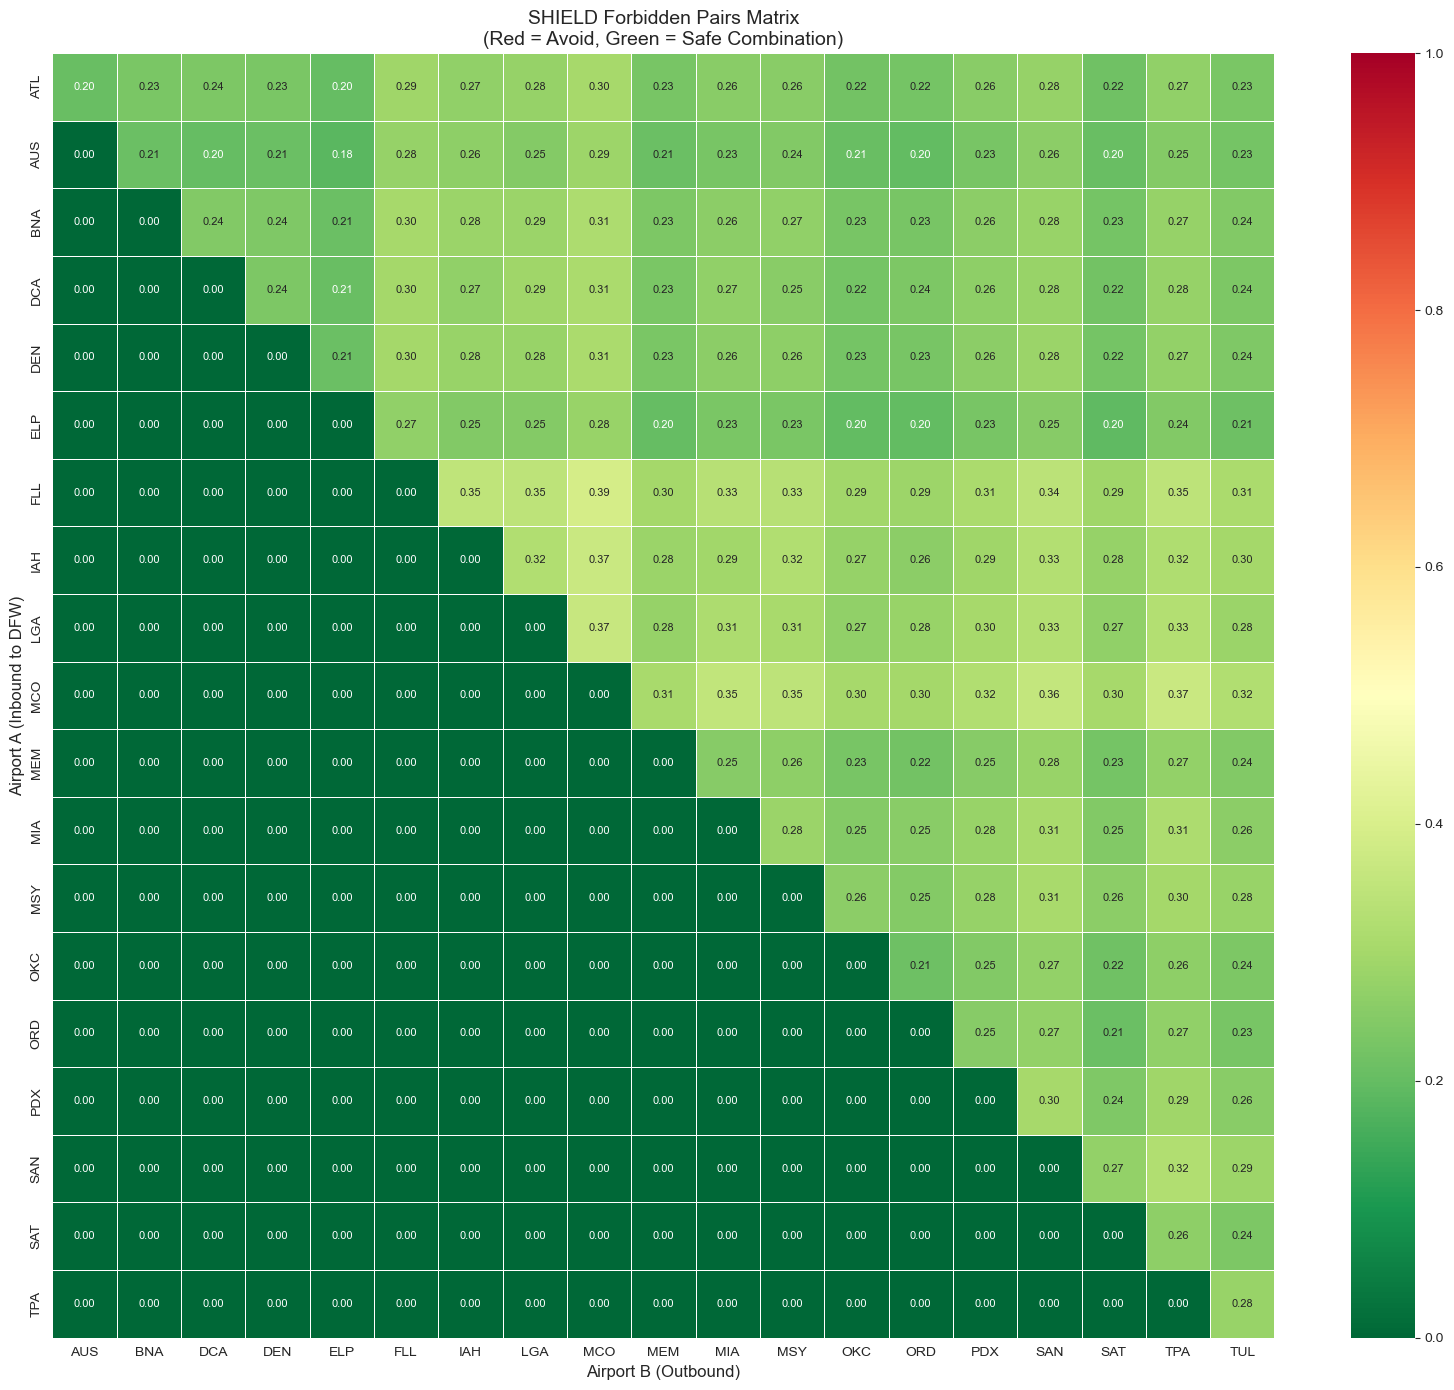

In [9]:
# Annual average pair risk matrix
pair_avg = pairs_df.groupby(['airport_A','airport_B'])['SHIELD_pair_score'].mean().reset_index()

# Top 20 airports only for readability
top20 = (
    risk_df.groupby('ORIGIN')['risk_score']
    .mean()
    .nlargest(20)
    .index.tolist()
)

matrix_data = pair_avg[
    pair_avg['airport_A'].isin(top20) &
    pair_avg['airport_B'].isin(top20)
]

pivot = matrix_data.pivot(index='airport_A', columns='airport_B', values='SHIELD_pair_score').fillna(0)

plt.figure(figsize=(16, 14))
sns.heatmap(
    pivot,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    annot_kws={'size': 8},
    vmin=0, vmax=1
)
plt.title('SHIELD Forbidden Pairs Matrix\n(Red = Avoid, Green = Safe Combination)', fontsize=14)
plt.xlabel('Airport B (Outbound)', fontsize=12)
plt.ylabel('Airport A (Inbound to DFW)', fontsize=12)
plt.tight_layout()
plt.savefig('../report/forbidden_pairs_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Forbidden pairs matrix saved!")

FileNotFoundError: [Errno 2] No such file or directory: '../report/top10_forbidden_pairs.png'

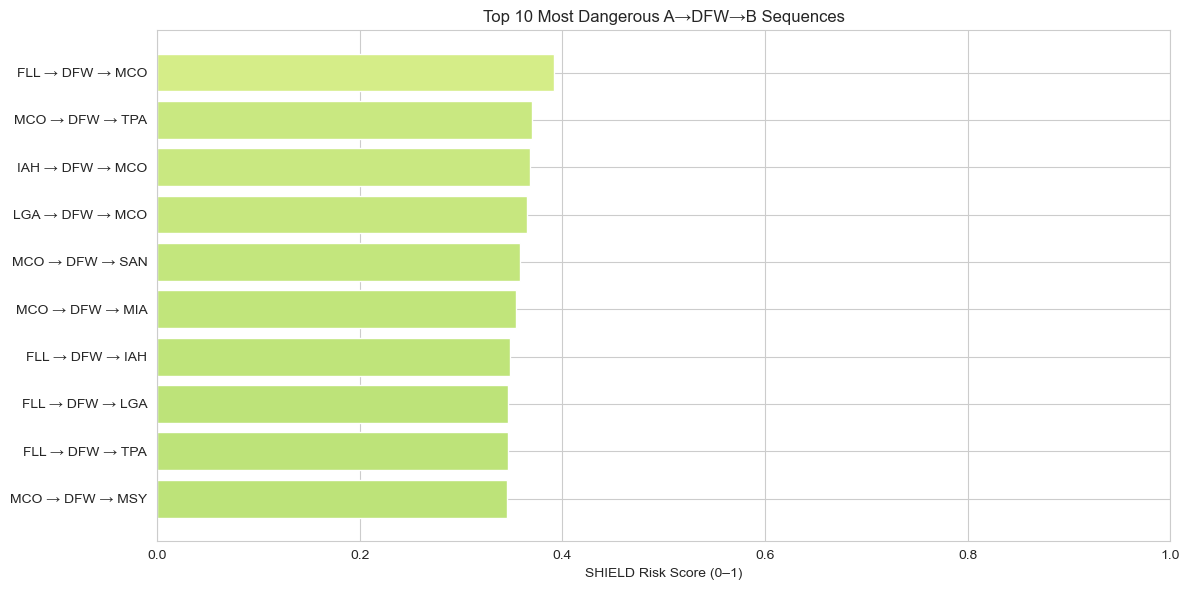

In [10]:
top10 = top_pairs.head(10).copy()
top10['pair_label'] = top10['airport_A'] + ' → DFW → ' + top10['airport_B']

plt.figure(figsize=(12, 6))
bars = plt.barh(top10['pair_label'], top10['avg_SHIELD_score'],
                color=plt.cm.RdYlGn_r(top10['avg_SHIELD_score']))
plt.xlabel('SHIELD Risk Score (0–1)')
plt.title('Top 10 Most Dangerous A→DFW→B Sequences')
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../report/top10_forbidden_pairs.png', dpi=200)
plt.show()